# 03 · Ngưỡng khoảng ngắt để cắt segment

**Câu hỏi:** Hai điểm GPS liên tiếp cách nhau bao lâu thì nên cắt thành segment (`sub_trip_id`) mới?

**Quyết định:** `CleaningThresholds.max_gap_seconds = 1200` (20 phút). Pipeline còn cắt segment tại bước nhảy > 1100 km/h (notebook 01).

**Vai trò của segment:** segment chỉ phục vụ **hiển thị** (không vẽ đường nối qua chỗ mất dữ liệu) và tính toán theo đoạn. Stay-point detection **không** chạy theo segment, mà chạy trên từng file `.plt` hoặc chuỗi file nối nhau (notebook 04, 06). Vì vậy ngưỡng này không ảnh hưởng tới stay-point hay Home/Office.

**Khái niệm:** *khoảng ngắt* là thời gian giữa hai điểm GPS liên tiếp **trong cùng một file**. Khoảng giữa hai file khác nhau (hai lần ghi độc lập) không được tính.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK = "03_segment_gap_threshold"
DATA_DIR = Path("../data/raw")
OUT_DIR = Path("outputs") / NOTEBOOK
FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR = (OUT_DIR / d for d in ("figures", "tables", "cache", "maps"))
for d in (FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
from gps.data.processing import (
    DEFAULT_THRESHOLDS, _haversine_vectorized, filter_physical_bounds, load_plt_file,
    remove_speed_spikes, resolve_duplicate_timestamps,
)

CURRENT_GAP_S = DEFAULT_THRESHOLDS.max_gap_seconds   # 1200 s
STAY_RADIUS_M = 200                                  # stay-point radius (notebook 07)
RAW_COLUMNS = ["lat", "lon", "reserved", "altitude", "date_days", "date_str", "time_str"]


def load_user_trajectory(user_id: str) -> pd.DataFrame | None:
    files = sorted((DATA_DIR / user_id / "Trajectory").glob("*.plt"))
    if not files:
        return None
    traj = pd.concat([pd.read_csv(f, skiprows=6, header=None, names=RAW_COLUMNS).assign(source_file=f.name)
                      for f in files], ignore_index=True)
    traj["timestamp"] = pd.to_datetime(traj["date_str"] + " " + traj["time_str"],
                                       format="%Y-%m-%d %H:%M:%S", errors="coerce")
    return traj.dropna(subset=["timestamp"]).sort_values(["source_file", "timestamp"]).reset_index(drop=True)


def load_labels(user_id: str) -> pd.DataFrame | None:
    path = DATA_DIR / user_id / "labels.txt"
    if not path.exists():
        return None
    df = pd.read_csv(path, sep="\t", skiprows=1, header=None, names=["start", "end", "mode"])
    df["start_dt"] = pd.to_datetime(df["start"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    df["end_dt"] = pd.to_datetime(df["end"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    return df.dropna(subset=["start_dt", "end_dt"]).reset_index(drop=True)[["start_dt", "end_dt", "mode"]]


def label_interval_index(timestamps: pd.Series, labels: pd.DataFrame) -> np.ndarray:
    """Index of the label row each point falls in (-1 if none). Using the row index, not the
    mode, distinguishes two consecutive trips with the same mode (e.g. walk, walk)."""
    idx = np.full(len(timestamps), -1, dtype=int)
    ts = timestamps.to_numpy()
    for i, (start, end) in enumerate(zip(labels["start_dt"], labels["end_dt"], strict=True)):
        idx[(ts >= np.datetime64(start)) & (ts <= np.datetime64(end))] = i
    return idx


def labelled_gaps(traj: pd.DataFrame, labels: pd.DataFrame) -> pd.DataFrame:
    """Gaps between consecutive points of the SAME file, both inside a label interval:
    within_trip = same interval, cross_trip = two different intervals (a real trip boundary)."""
    interval = label_interval_index(traj["timestamp"], labels)
    gap = traj["timestamp"].diff().dt.total_seconds().to_numpy()[1:]
    same_file = (traj["source_file"].to_numpy()[1:] == traj["source_file"].to_numpy()[:-1])
    prev_i, next_i = interval[:-1], interval[1:]
    ok = same_file & (prev_i != -1) & (next_i != -1) & (gap > 0)
    return pd.DataFrame({"gap_s": gap[ok],
                         "category": np.where(prev_i == next_i, "within_trip", "cross_trip")[ok]})

## Phần 1 · Khoảng ngắt bên trong một chuyến và giữa hai chuyến (69 user có nhãn)

Dùng `labels.txt` để phân loại mỗi khoảng ngắt:
- **within_trip:** hai điểm thuộc cùng một chuyến có nhãn, tức GPS tạm im lặng nhưng vẫn là một chuyến;
- **cross_trip:** hai điểm thuộc hai chuyến khác nhau, tức ranh giới thật giữa hai chuyến.

Nếu phân phối của hai nhóm tách nhau rõ, sẽ tìm được ngưỡng phân biệt được chúng.

In [2]:
GAPS_PATH = CACHE_DIR / "labeled_gaps.parquet"
if GAPS_PATH.exists():
    gap_df = pd.read_parquet(GAPS_PATH)
else:
    users = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir())
    labeled_users = [u for u in users if (DATA_DIR / u / "labels.txt").exists()]
    parts = []
    for i, user_id in enumerate(labeled_users, start=1):
        print(f"\r[{i}/{len(labeled_users)}] user {user_id}", end="", flush=True)
        traj, labels = load_user_trajectory(user_id), load_labels(user_id)
        if traj is not None and labels is not None:
            parts.append(labelled_gaps(traj, labels).assign(user_id=user_id))
    print()
    gap_df = pd.concat(parts, ignore_index=True)
    gap_df.to_parquet(GAPS_PATH)

within = gap_df.loc[gap_df["category"] == "within_trip", "gap_s"]
cross = gap_df.loc[gap_df["category"] == "cross_trip", "gap_s"]
q = [0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99, 0.999, 0.9999]
gap_stats = gap_df.groupby("category")["gap_s"].describe(percentiles=q).T
gap_stats.to_csv(TABLE_DIR / "gap_stats_by_category.csv")
gap_stats.round(1)

category,cross_trip,within_trip
count,4171.0,4856027.0
mean,1065.6,4.0
std,3171.7,67.4
min,1.0,1.0
1%,1.0,1.0
5%,2.0,1.0
10%,2.0,1.0
50%,5.0,2.0
90%,2556.0,5.0
95%,7639.0,6.0


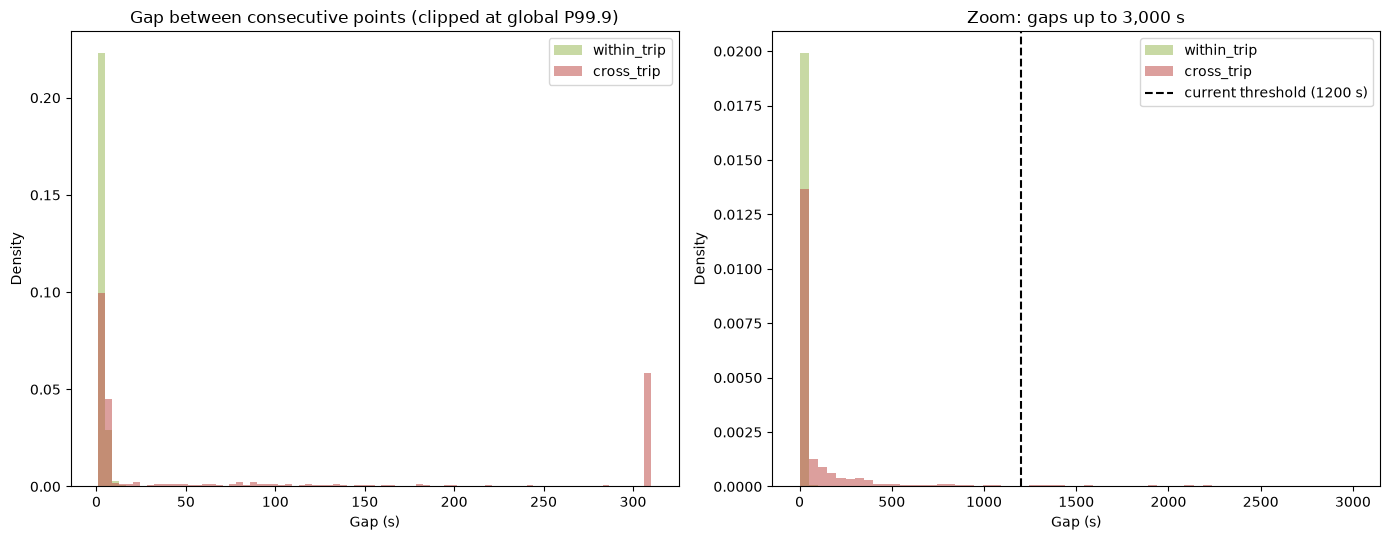

In [3]:
cap = gap_df["gap_s"].quantile(0.999)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for cat, color in [("within_trip", "#9bbb59"), ("cross_trip", "#c0504d")]:
    axes[0].hist(gap_df.loc[gap_df["category"] == cat, "gap_s"].clip(upper=cap), bins=80, alpha=0.55,
                 density=True, color=color, label=cat)
    axes[1].hist(gap_df.loc[(gap_df["category"] == cat) & (gap_df["gap_s"] <= 3000), "gap_s"], bins=60,
                 alpha=0.55, density=True, color=color, label=cat)
axes[0].set_title("Gap between consecutive points (clipped at global P99.9)")
axes[1].axvline(CURRENT_GAP_S, color="black", linestyle="--", label=f"current threshold ({CURRENT_GAP_S:.0f} s)")
axes[1].set_title("Zoom: gaps up to 3,000 s")
for ax in axes:
    ax.set_xlabel("Gap (s)")
    ax.set_ylabel("Density")
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_gap_within_vs_cross_trip.png", dpi=150, bbox_inches="tight")
plt.show()

### Có tìm được ngưỡng tách hai nhóm không?

Với mỗi ngưỡng ứng viên, đo hai loại lỗi:
- **cắt oan:** khoảng ngắt within_trip lớn hơn ngưỡng, nên một chuyến bị cắt đôi;
- **bỏ sót:** khoảng ngắt cross_trip không vượt ngưỡng, nên ranh giới thật giữa hai chuyến không được phát hiện.

In [4]:
rows = [{"threshold_s": thr, "threshold_min": thr / 60,
         "within_trip_split_pct": 100 * (within > thr).mean(),
         "cross_trip_missed_pct": 100 * (cross <= thr).mean()}
        for thr in [300, 600, 900, 1200, 1500, 1800, 2400, 3600]]
candidates = pd.DataFrame(rows)
candidates.to_csv(TABLE_DIR / "gap_threshold_candidates.csv", index=False)
cross_le_5s, cross_le_60s = 100 * (cross <= 5).mean(), 100 * (cross <= 60).mean()
print(f"Real trip boundaries with a gap <= 5 s : {cross_le_5s:.1f}%")
print(f"Real trip boundaries with a gap <= 60 s: {cross_le_60s:.1f}%")
candidates.round(2)

Real trip boundaries with a gap <= 5 s : 55.4%
Real trip boundaries with a gap <= 60 s: 62.3%


,threshold_s,threshold_min,within_trip_split_pct,cross_trip_missed_pct
0,300,5.0,0.08,77.27
1,600,10.0,0.04,82.28
2,900,15.0,0.03,84.44
3,1200,20.0,0.02,85.83
4,1500,25.0,0.02,87.29
5,1800,30.0,0.01,88.11
6,2400,40.0,0.01,89.62
7,3600,60.0,0.00,90.79


**Đọc kết quả:** tỉ lệ bỏ sót không bao giờ xuống thấp, dù chọn ngưỡng nào, vì một phần lớn ranh giới chuyến đi thật **gần như không có khoảng ngắt**. Ví dụ người dùng xuống xe buýt rồi đi bộ tiếp, thiết bị vẫn ghi liên tục. Đó là giới hạn của dữ liệu, không phải lỗi chọn ngưỡng. Vì vậy **dùng khoảng ngắt để tìm chuyến đi là không khả thi**, và không nên chọn ngưỡng theo kiểu "cân bằng hai loại lỗi".

Mục đích còn lại, và hợp lý, của ngưỡng là **không cắt oan một chuyến đang ghi liên tục**. Vì vậy ngưỡng được neo theo **đuôi phân phối within_trip**.

In [5]:
p999, p9999 = within.quantile(0.999), within.quantile(0.9999)
print(f"within_trip P99.9  = {p999:.1f} s ({p999 / 60:.1f} min)")
print(f"within_trip P99.99 = {p9999:.1f} s ({p9999 / 60:.1f} min)")
print(f"At {CURRENT_GAP_S:.0f} s only {100 * (within > CURRENT_GAP_S).mean():.3f}% of within-trip gaps are split.")

within_trip P99.9  = 252.0 s (4.2 min)
within_trip P99.99 = 2170.0 s (36.2 min)
At 1200 s only 0.020% of within-trip gaps are split.


## Phần 2 · Khoảng ngắt trên toàn bộ 182 user

Câu hỏi thực tế: khi khoảng ngắt > 20 phút mà người dùng vẫn đứng yên (ví dụ ngắt 21 phút trong toà nhà), thì ngưỡng cắt segment có làm mất stay-point (cần ≥ 30 phút) không? Có nên nâng ngưỡng lên 30 phút không?

Dữ liệu đi qua đúng các bước làm sạch của pipeline (`filter_physical_bounds` → `resolve_duplicate_timestamps` → `remove_speed_spikes`). Với mỗi khoảng ngắt, đo thêm **quãng dịch chuyển**: ≤ 200 m nghĩa là **đứng yên** (theo bán kính stay-point). Khoảng giữa hai file được đếm riêng, không đưa vào phân tích.

In [6]:
def user_gaps(user_id: str) -> pd.DataFrame | None:
    parts = []
    for f in sorted((DATA_DIR / user_id / "Trajectory").glob("*.plt")):
        df = filter_physical_bounds(load_plt_file(f), DEFAULT_THRESHOLDS)
        if len(df) < 2:
            continue
        df, _ = resolve_duplicate_timestamps(df, DEFAULT_THRESHOLDS)
        df, _ = remove_speed_spikes(df, DEFAULT_THRESHOLDS)
        parts.append(df.assign(file=f.name))
    if not parts:
        return None
    u = pd.concat(parts, ignore_index=True).sort_values(["datetime", "file"], kind="stable")
    ts = u["datetime"].to_numpy("datetime64[ns]")
    lat, lon, fl = u["lat"].to_numpy(), u["lon"].to_numpy(), u["file"].to_numpy()
    dt = (ts[1:] - ts[:-1]) / np.timedelta64(1, "s")
    keep = dt > 0
    dist = _haversine_vectorized(lat[:-1], lon[:-1], lat[1:], lon[1:])
    return pd.DataFrame({"user_id": user_id, "gap_s": dt[keep], "dist_m": dist[keep],
                         "cross_file": (fl[:-1] != fl[1:])[keep]})


ALL_GAPS_PATH = CACHE_DIR / "all_user_gaps.parquet"
if ALL_GAPS_PATH.exists():
    all_gaps = pd.read_parquet(ALL_GAPS_PATH)
else:
    users = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir())
    frames = []
    for i, user_id in enumerate(users, start=1):
        print(f"\r[{i}/{len(users)}] user {user_id}", end="", flush=True)
        g = user_gaps(user_id)
        if g is not None:
            frames.append(g)
    print()
    all_gaps = pd.concat(frames, ignore_index=True)
    all_gaps.to_parquet(ALL_GAPS_PATH)

print(f"Consecutive pairs: {len(all_gaps):,} (between two files, excluded below: {int(all_gaps['cross_file'].sum()):,})")
gaps = all_gaps[~all_gaps["cross_file"]].copy()
gaps["stationary"] = gaps["dist_m"] <= STAY_RADIUS_M
print(gaps["gap_s"].quantile([0.5, 0.9, 0.99, 0.999, 0.9999]).rename("gap_s").round(1).to_string())

Consecutive pairs: 24,177,312 (between two files, excluded below: 18,488)
0.5000        2.0
0.9000        5.0
0.9900       20.0
0.9990      602.0
0.9999    10652.0


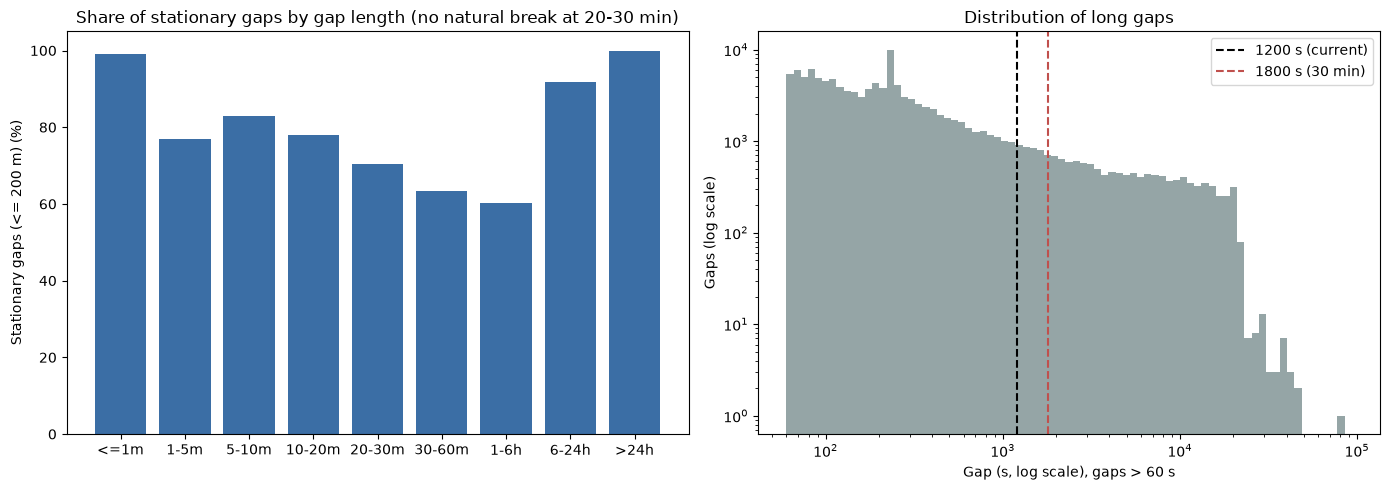

,n_gaps,stationary_pct,median_dist_m,n_users,share_pct
band,,,,,
<=1m,24038413,99.20,9.16,182,99.50
1-5m,80600,77.01,29.21,181,0.33
5-10m,15604,82.88,28.49,174,0.06
10-20m,8783,77.84,29.15,172,0.04
20-30m,3583,70.36,31.06,157,0.01
30-60m,4499,63.37,80.36,156,0.02
1-6h,7292,60.35,126.54,171,0.03
6-24h,49,91.84,25.85,19,0.00
>24h,1,100.00,6.14,1,0.00


In [7]:
BANDS = [0, 60, 300, 600, 1200, 1800, 3600, 6 * 3600, 24 * 3600, np.inf]
BAND_LABELS = ["<=1m", "1-5m", "5-10m", "10-20m", "20-30m", "30-60m", "1-6h", "6-24h", ">24h"]
gaps["band"] = pd.cut(gaps["gap_s"], BANDS, labels=BAND_LABELS)
bands = gaps.groupby("band", observed=False).agg(
    n_gaps=("gap_s", "size"), stationary_pct=("stationary", lambda s: 100 * s.mean()),
    median_dist_m=("dist_m", "median"), n_users=("user_id", "nunique"))
bands["share_pct"] = 100 * bands["n_gaps"] / len(gaps)
bands.to_csv(TABLE_DIR / "gap_bands_within_file.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BAND_LABELS))
axes[0].bar(x, bands["stationary_pct"], color="#3b6ea5")
axes[0].set_xticks(x, BAND_LABELS)
axes[0].set_ylabel(f"Stationary gaps (<= {STAY_RADIUS_M} m) (%)")
axes[0].set_title("Share of stationary gaps by gap length (no natural break at 20-30 min)")
long_gaps = gaps.loc[gaps["gap_s"] > 60, "gap_s"]
axes[1].hist(long_gaps, bins=np.logspace(np.log10(60), np.log10(long_gaps.max()), 80), color="#95a5a6")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
for thr, color, lbl in [(1200, "black", "1200 s (current)"), (1800, "#c0504d", "1800 s (30 min)")]:
    axes[1].axvline(thr, color=color, linestyle="--", label=lbl)
axes[1].set_xlabel("Gap (s, log scale), gaps > 60 s")
axes[1].set_ylabel("Gaps (log scale)")
axes[1].set_title("Distribution of long gaps")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_gap_bands_within_file.png", dpi=150, bbox_inches="tight")
plt.show()
bands.round(2)

In [8]:
between = (gaps["gap_s"] > 1200) & (gaps["gap_s"] <= 1800)
print(f"Gaps between 20 and 30 min: {between.sum():,} ({100 * between.mean():.4f}% of pairs), "
      f"stationary {100 * gaps.loc[between, 'stationary'].mean():.1f}%")
for thr in [1200, 1800]:
    cut = gaps["gap_s"] > thr
    print(f"Threshold {thr} s cuts {cut.sum():,} gaps, of which stationary {100 * gaps.loc[cut, 'stationary'].mean():.1f}%")

Gaps between 20 and 30 min: 3,583 (0.0148% of pairs), stationary 70.4%
Threshold 1200 s cuts 15,424 gaps, of which stationary 63.7%
Threshold 1800 s cuts 11,841 gaps, of which stationary 61.6%


## Kết luận

- **Giữ `max_gap_seconds = 1200`.** Giá trị này nằm trong khoảng P99.9 (252 s) – P99.99 (2,170 s) của khoảng ngắt bên trong một chuyến; ở 1200 s chỉ 0.02% khoảng ngắt trong chuyến bị cắt oan. Con số 1800 cũng nằm trong khoảng đó, nhưng không có số liệu nào cho thấy nó tốt hơn.
- **Tỉ lệ đứng yên giảm dần đều theo độ dài khoảng ngắt**, không có điểm gãy tự nhiên giữa 20 và 30 phút. Khoảng ngắt 20–30 phút chỉ chiếm 0.015% số cặp điểm.
- **Cắt segment không xoá điểm nào**: điểm sau khoảng ngắt chỉ nhận một `sub_trip_id` mới. Stay-point chạy theo từng file, không theo segment, nên khoảng ngắt 21 phút trong lúc đứng yên vẫn nằm trong stay-point nếu cả lần dừng dài ≥ 30 phút.
- **Khoảng ngắt không phải ranh giới chuyến đi**: 55.4% ranh giới chuyến thật có khoảng ngắt ≤ 5 giây, và 63.7% số khoảng ngắt bị cắt ở 1200 s là lúc người dùng đứng yên.

*Ghi chú phương pháp:* khoảng ngắt chỉ được tính trong cùng một file. Bản trước của phân tích này nối các file của user lại, nên lẫn cả khoảng giữa hai file, và cho ra P99.99 = 2,600 s và 34.6% ranh giới ≤ 5 s. Kết luận vẫn giữ nguyên.

In [9]:
decision = pd.DataFrame([
    {"metric": "within_trip_gap_p99_9_s", "value": round(float(p999), 1), "basis": "P99.9 of gaps inside one labelled trip (same file)"},
    {"metric": "within_trip_gap_p99_99_s", "value": round(float(p9999), 1), "basis": "P99.99 of gaps inside one labelled trip (same file)"},
    {"metric": "max_gap_seconds", "value": CURRENT_GAP_S, "basis": "chosen: inside the P99.9-P99.99 range"},
    {"metric": "trip_boundaries_gap_le_5s_pct", "value": round(float(cross_le_5s), 1), "basis": "share of real trip boundaries no gap threshold can detect"},
    {"metric": "gaps_20_30min_pct", "value": round(float(100 * between.mean()), 4), "basis": "share of within-file gaps between 1200 and 1800 s"},
])
decision.to_csv(TABLE_DIR / "segment_threshold_decision.csv", index=False)
decision

,metric,value,basis
0,within_trip_gap_p99_9_s,252.0000,P99.9 of gaps inside one labelled trip (same f...
1,within_trip_gap_p99_99_s,2170.0000,P99.99 of gaps inside one labelled trip (same ...
2,max_gap_seconds,1200.0000,chosen: inside the P99.9-P99.99 range
3,trip_boundaries_gap_le_5s_pct,55.4000,share of real trip boundaries no gap threshold...
4,gaps_20_30min_pct,0.0148,share of within-file gaps between 1200 and 1800 s
